# Notebook 1 — IDRiD Segmentation Preprocessing
**Paper:** *A Comprehensive Deep-Learning Framework Integrating Lesion Segmentation and Stage Classification for Enhanced Diabetic Retinopathy Diagnosis*  
**Authors:** Incir & Bozkurt | Int J Imaging Syst Tech, 2026

---

## What this notebook does
Preprocesses the IDRiD segmentation dataset (81 high-resolution fundus images) and generates
training-ready patches for four lesion types:
**EX** (Hard Exudates), **HE** (Haemorrhages), **MA** (Microaneurysms), **SE** (Soft Exudates).

## Pipeline (Section 3.3 of the paper)
1. Mount Google Drive + install dependencies  
2. Extract `A. Segmentation.zip` to Colab local SSD (faster than Drive I/O)  
3. Build image index → **80 / 10 / 10** image-level split  
4. Remove optic disc using ground-truth OD masks  
5. Resize → 4096x2560 → patch 1024x1024 (50% overlap) → filter empty → resize 224x224  
6. Augment training patches x3 (rotation, noise, sharpening, flip, crop)  
7. Save compressed `.npz` files to Drive  

## Expected I/O
| | Path |
|---|---|
| **Input** | `MyDrive/DR_PROJECT/datasets/A. Segmentation.zip` |
| **Output** | `MyDrive/DR_PROJECT/preprocessed/segmentation/{EX,HE,MA,SE}/{train,val,test}.npz` |

> **Note:** GPU is not required for this notebook. CPU is sufficient.

## Cell 1 — Mount Drive & Install Dependencies

In [8]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q tqdm

import os, random, zipfile
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

print('Libraries loaded.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries loaded.


## Cell 2 — Configuration
All paths and paper-specified preprocessing parameters in one place.  
Change `BASE_PATH` if your Google Drive folder structure differs.

In [9]:
BASE_PATH     = '/content/drive/MyDrive/DR_PROJECT/datasets'
OUTPUT_BASE   = '/content/drive/MyDrive/DR_PROJECT/preprocessed'
IDRID_SEG_ZIP = os.path.join(BASE_PATH, 'A. Segmentation.zip')

EXTRACT_DIR = '/content/idrid_seg'  # Colab local SSD — fast I/O during processing
os.makedirs(EXTRACT_DIR, exist_ok=True)
os.makedirs(OUTPUT_BASE, exist_ok=True)

# ---- Paper preprocessing parameters (Section 3.3) ----
RESIZE_W, RESIZE_H = 4096, 2560  # resize before patching
PATCH_SIZE  = 1024
STRIDE      = 512                 # 50% overlap -> 28 patches per image (max)
FINAL_SIZE  = 224                 # CNN input size
AUGMENT_FACTOR = 3                # 3 new variants per original patch (training only)
RANDOM_SEED = 42

LESIONS = ['EX', 'HE', 'MA', 'SE']

LESION_FOLDER_MAP = {
    'EX': '3. Hard Exudates',
    'HE': '2. Haemorrhages',
    'MA': '1. Microaneurysms',
    'SE': '4. Soft Exudates',
}
LESION_SUFFIX_MAP = {'EX': '_EX', 'HE': '_HE', 'MA': '_MA', 'SE': '_SE'}

print(f'Resize  : {RESIZE_W} x {RESIZE_H}')
print(f'Patch   : {PATCH_SIZE} x {PATCH_SIZE}  stride {STRIDE}  (50% overlap)')
print(f'Final   : {FINAL_SIZE} x {FINAL_SIZE}')
print(f'Augment : x{AUGMENT_FACTOR} on training patches only')

Resize  : 4096 x 2560
Patch   : 1024 x 1024  stride 512  (50% overlap)
Final   : 224 x 224
Augment : x3 on training patches only


## Cell 3 — Validate Zip & Build File Index

Reads the zip's table of contents **without extracting anything to disk**.  
This is more reliable than extraction: no local storage limit, survives Drive remounts between cells, and avoids the risk of re-running a slow extract after a disconnect.

`load_from_zip()` is defined here — it decodes images directly from the zip byte stream using OpenCV, exactly as your earlier working script did.

In [10]:
print('Reading zip table of contents (no extraction)...')
with zipfile.ZipFile(IDRID_SEG_ZIP, 'r') as zf:
    ALL_ZIP_NAMES = set(zf.namelist())
print(f'Total entries in zip: {len(ALL_ZIP_NAMES)}')

# Auto-detect the prefix inside the zip — handles zips with or without a top-level folder
# e.g.  "A. Segmentation/1. Original Images/..."  OR  "1. Original Images/..."
SEG_PREFIX = ''
for n in sorted(ALL_ZIP_NAMES):
    if '1. Original Images' in n and n.endswith('.jpg'):
        SEG_PREFIX = n[:n.index('1. Original Images')]
        break

print(f'Zip internal prefix: "{SEG_PREFIX}"')

TRAIN_IMG_ZIP  = f'{SEG_PREFIX}1. Original Images/a. Training Set/'
TEST_IMG_ZIP   = f'{SEG_PREFIX}1. Original Images/b. Testing Set/'
TRAIN_MASK_ZIP = f'{SEG_PREFIX}2. All Segmentation Groundtruths/a. Training Set/'
TEST_MASK_ZIP  = f'{SEG_PREFIX}2. All Segmentation Groundtruths/b. Testing Set/'

# Verify counts match IDRiD spec (54 train / 27 test)
train_img_list = sorted(n for n in ALL_ZIP_NAMES if n.startswith(TRAIN_IMG_ZIP) and n.endswith('.jpg'))
test_img_list  = sorted(n for n in ALL_ZIP_NAMES if n.startswith(TEST_IMG_ZIP)  and n.endswith('.jpg'))
print(f'\nTrain images : {len(train_img_list)}')
print(f'Test  images : {len(test_img_list)}')
for lesion, folder in LESION_FOLDER_MAP.items():
    prefix = f'{TRAIN_MASK_ZIP}{folder}/'
    count  = sum(1 for z in ALL_ZIP_NAMES if z.startswith(prefix) and z.endswith('.tif'))
    print(f'Train {lesion} masks: {count}')


def load_from_zip(zf, zip_path, grayscale=False):
    '''Read an image directly from an open ZipFile object without extracting to disk.
    Returns None if the path is not in the zip (handles missing SE annotations gracefully).
    '''
    if zip_path not in ALL_ZIP_NAMES:
        return None
    with zf.open(zip_path) as f:
        buf  = np.frombuffer(f.read(), np.uint8)
        flag = cv2.IMREAD_GRAYSCALE if grayscale else cv2.IMREAD_COLOR
        return cv2.imdecode(buf, flag)


print('\nload_from_zip() ready.')

Reading zip table of contents (no extraction)...
Total entries in zip: 463
Zip internal prefix: "A. Segmentation/"

Train images : 54
Test  images : 27
Train EX masks: 54
Train HE masks: 53
Train MA masks: 54
Train SE masks: 26

load_from_zip() ready.


## Cell 4 — Build Image Index & 80/10/10 Split

Builds a list of dictionaries — one per image — storing the **zip-internal paths** for the image,
its OD mask, and its mask directory. No files are opened here; paths are just recorded.

The 80/10/10 split is assigned at **image level** (not patch level) to prevent data leakage
where patches from the same fundus appear in both training and test sets.

In [11]:
def _build_entry(img_zip_path, mask_zip_root):
    fname  = img_zip_path.split('/')[-1]
    img_id = fname.split('_')[1].split('.')[0]  # 'IDRiD_01.jpg' -> '01'
    return {
        'fname':         fname,
        'img_id':        img_id,
        'img_zip':       img_zip_path,
        'od_zip':        f'{mask_zip_root}5. Optic Disc/IDRiD_{img_id}_OD.tif',
        'mask_root_zip': mask_zip_root,
    }

all_images = []
for p in train_img_list:
    all_images.append(_build_entry(p, TRAIN_MASK_ZIP))
for p in test_img_list:
    all_images.append(_build_entry(p, TEST_MASK_ZIP))

print(f'Total images indexed: {len(all_images)}')

# 80/10/10 image-level split (reproducible with fixed seed)
random.seed(RANDOM_SEED)
indices = list(range(len(all_images)))
random.shuffle(indices)
n = len(indices)
n_train, n_val = int(0.8 * n), int(0.1 * n)

split_map = {}
for rank, idx in enumerate(indices):
    if rank < n_train:               split_map[idx] = 'train'
    elif rank < n_train + n_val:     split_map[idx] = 'val'
    else:                            split_map[idx] = 'test'

for idx, info in enumerate(all_images):
    info['split'] = split_map[idx]

counts = {s: sum(1 for i in all_images if i['split'] == s) for s in ['train', 'val', 'test']}
print(f'Image split -> train: {counts["train"]}, val: {counts["val"]}, test: {counts["test"]}')

print('\nSample assignments (first 6 images):')
for info in all_images[:6]:
    print(f'  {info["fname"]}  ->  {info["split"]}')

Total images indexed: 81
Image split -> train: 64, val: 8, test: 9

Sample assignments (first 6 images):
  IDRiD_01.jpg  ->  train
  IDRiD_02.jpg  ->  train
  IDRiD_03.jpg  ->  train
  IDRiD_04.jpg  ->  test
  IDRiD_05.jpg  ->  val
  IDRiD_06.jpg  ->  train


## Cell 5 — Preprocessing & Augmentation Functions

| Function | Purpose |
|---|---|
| `load_rgb` | Load image as RGB (OpenCV loads as BGR by default) |
| `remove_optic_disc` | Inpaint OD region using the ground-truth OD mask |
| `extract_patches` | Slide 1024x1024 window; keep only patches with lesion content |
| `to_final` | Resize patch to 224x224 (nearest-neighbor for mask to keep binary values) |
| `aug_rotate_noise` | Variant 1: random rotation + Gaussian noise |
| `aug_sharpen_flip` | Variant 2: unsharp masking + horizontal flip |
| `aug_crop_rotate` | Variant 3: random 80–95% crop + rotation |

In [12]:
def remove_optic_disc(image, od_mask):
    '''Replace OD region with inpainted content (Section 3.3).
    The OD is a bright non-pathological structure that mimics hard exudates.
    Uses ground-truth OD masks (IDRiD folder 5. Optic Disc) for pixel-accurate removal.
    IDRiD masks store lesion pixels as 1, so threshold is > 0.
    '''
    binary  = (od_mask > 0).astype(np.uint8) * 255
    kernel  = np.ones((20, 20), np.uint8)
    dilated = cv2.dilate(binary, kernel, iterations=2)
    return cv2.inpaint(image, dilated, inpaintRadius=7, flags=cv2.INPAINT_TELEA)


def extract_patches(image, mask):
    '''Sliding 1024x1024 window with stride=512 (50% overlap).
    Only keeps patches where the lesion mask contains at least one positive pixel.
    '''
    h, w = image.shape[:2]
    patches = []
    for y in range(0, h - PATCH_SIZE + 1, STRIDE):
        for x in range(0, w - PATCH_SIZE + 1, STRIDE):
            ip = image[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            mp = mask[y:y+PATCH_SIZE,  x:x+PATCH_SIZE]
            if mp.max() > 0:
                patches.append((ip, mp))
    return patches


def to_final(img, msk):
    '''Resize to 224x224. INTER_NEAREST for mask preserves 0/255 binary values.
    IDRiD masks use pixel value 1 for lesions; > 0 handles both 0/1 and 0/255 formats.
    '''
    img_r = cv2.resize(img, (FINAL_SIZE, FINAL_SIZE), interpolation=cv2.INTER_LINEAR)
    msk_r = cv2.resize(msk, (FINAL_SIZE, FINAL_SIZE), interpolation=cv2.INTER_NEAREST)
    return img_r, (msk_r > 0).astype(np.uint8) * 255


def _rot(img, angle, is_mask=False):
    '''Rotate around center with reflection border fill.'''
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    interp = cv2.INTER_NEAREST if is_mask else cv2.INTER_LINEAR
    return cv2.warpAffine(img, M, (w, h), flags=interp, borderMode=cv2.BORDER_REFLECT)


def aug_rotate_noise(img, msk):
    '''Variant 1: random discrete rotation + Gaussian noise (σ=8).'''
    angle = random.choice([15, 30, 45, 90, 135, 180, 270])
    img   = _rot(img, angle)
    msk   = _rot(msk, angle, is_mask=True)
    noise = np.random.normal(0, 8, img.shape).astype(np.int16)
    img   = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    return img, msk


def aug_sharpen_flip(img, msk):
    '''Variant 2: unsharp masking + horizontal flip.'''
    blurred   = cv2.GaussianBlur(img, (0, 0), 3)
    sharpened = cv2.addWeighted(img, 1.5, blurred, -0.5, 0)
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
    return cv2.flip(sharpened, 1), cv2.flip(msk, 1)


def aug_crop_rotate(img, msk):
    '''Variant 3: rotation + random 80–95% crop.'''
    angle = random.choice([15, 45, 90, 135])
    img   = _rot(img, angle)
    msk   = _rot(msk, angle, is_mask=True)
    h, w  = img.shape[:2]
    scale = random.uniform(0.80, 0.95)
    nh, nw = int(h * scale), int(w * scale)
    y0, x0 = random.randint(0, h - nh), random.randint(0, w - nw)
    return img[y0:y0+nh, x0:x0+nw], msk[y0:y0+nh, x0:x0+nw]


AUG_FNS = [aug_rotate_noise, aug_sharpen_flip, aug_crop_rotate]

print('All preprocessing functions defined.')

All preprocessing functions defined.


## Cell 6 — Run Preprocessing
Processes one lesion type at a time. Expected duration: **~20–35 min total** (CPU only, no GPU needed).

**If Colab disconnects:** re-run from Cell 1. The function checks for existing `.npz` files
and skips any lesion that has already been fully processed.

> **Expected SE messages:** SE (Soft Exudates) is only annotated in ~40 of the 81 IDRiD images.  
> `continue` (skip) messages for the other ~41 images are **normal and expected**.

In [13]:
def preprocess_lesion(lesion):
    out_dir = os.path.join(OUTPUT_BASE, 'segmentation', lesion)
    os.makedirs(out_dir, exist_ok=True)

    # Idempotent: skip if all three split files already exist on Drive
    if all(os.path.exists(os.path.join(out_dir, f'{s}.npz')) for s in ['train', 'val', 'test']):
        print(f'[{lesion}] Already preprocessed - skipping.')
        return

    buf = {s: {'images': [], 'masks': []} for s in ['train', 'val', 'test']}

    # Open zip once for all 81 images — single file handle, reads directly from Drive
    with zipfile.ZipFile(IDRID_SEG_ZIP, 'r') as zf:
        for info in tqdm(all_images, desc=f'[{lesion}]'):
            mask_zip = (f"{info['mask_root_zip']}{LESION_FOLDER_MAP[lesion]}/"
                        f"IDRiD_{info['img_id']}{LESION_SUFFIX_MAP[lesion]}.tif")

            # load_from_zip returns None if path not in zip (e.g. missing SE annotations)
            mask = load_from_zip(zf, mask_zip, grayscale=True)
            if mask is None:
                continue

            image = load_from_zip(zf, info['img_zip'])
            if image is None:
                print(f"  Warning: could not load {info['fname']}")
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            od = load_from_zip(zf, info['od_zip'], grayscale=True)

            # Step 1: Remove optic disc (inpaint with ground-truth OD mask)
            if od is not None:
                image = remove_optic_disc(image, od)

            # Step 2: Resize to 4096x2560 (paper Section 3.3)
            image = cv2.resize(image, (RESIZE_W, RESIZE_H), interpolation=cv2.INTER_LINEAR)
            mask  = cv2.resize(mask,  (RESIZE_W, RESIZE_H), interpolation=cv2.INTER_NEAREST)
            # IDRiD masks use pixel value 1 for lesions (not 255) — threshold > 0 is correct
            mask  = (mask > 0).astype(np.uint8) * 255

            # Step 3: Sliding window — keep only patches with at least one lesion pixel
            patches = extract_patches(image, mask)
            if not patches:
                continue

            split = info['split']
            for ip, mp in patches:
                img_f, msk_f = to_final(ip, mp)
                buf[split]['images'].append(img_f)
                buf[split]['masks'].append(msk_f)

                # Augment training patches x3 at 1024px scale before final resize
                if split == 'train':
                    for aug_fn in AUG_FNS:
                        ai, am = aug_fn(ip, mp)
                        ai, am = to_final(ai, am)
                        buf[split]['images'].append(ai)
                        buf[split]['masks'].append(am)

    # Save compressed numpy archives to Drive
    for split, data in buf.items():
        if not data['images']:
            print(f'  WARNING: 0 patches for {lesion}/{split}')
            continue
        imgs = np.stack(data['images']).astype(np.uint8)  # (N, 224, 224, 3)
        msks = np.stack(data['masks']).astype(np.uint8)   # (N, 224, 224)
        path = os.path.join(out_dir, f'{split}.npz')
        np.savez_compressed(path, images=imgs, masks=msks)
        print(f'  [{lesion}/{split}] {imgs.shape[0]} patches saved -> {path}')


for lesion in LESIONS:
    print(f"\n{'='*50}\nLesion: {lesion}\n{'='*50}")
    preprocess_lesion(lesion)

print('\nAll lesions preprocessed!')


Lesion: EX


[EX]: 100%|██████████| 81/81 [04:52<00:00,  3.62s/it]


  [EX/train] 5276 patches saved -> /content/drive/MyDrive/DR_PROJECT/preprocessed/segmentation/EX/train.npz
  [EX/val] 136 patches saved -> /content/drive/MyDrive/DR_PROJECT/preprocessed/segmentation/EX/val.npz
  [EX/test] 145 patches saved -> /content/drive/MyDrive/DR_PROJECT/preprocessed/segmentation/EX/test.npz

Lesion: HE


[HE]: 100%|██████████| 81/81 [04:32<00:00,  3.36s/it]


  [HE/train] 4968 patches saved -> /content/drive/MyDrive/DR_PROJECT/preprocessed/segmentation/HE/train.npz
  [HE/val] 133 patches saved -> /content/drive/MyDrive/DR_PROJECT/preprocessed/segmentation/HE/val.npz
  [HE/test] 154 patches saved -> /content/drive/MyDrive/DR_PROJECT/preprocessed/segmentation/HE/test.npz

Lesion: MA


[MA]: 100%|██████████| 81/81 [05:01<00:00,  3.72s/it]


  [MA/train] 5616 patches saved -> /content/drive/MyDrive/DR_PROJECT/preprocessed/segmentation/MA/train.npz
  [MA/val] 151 patches saved -> /content/drive/MyDrive/DR_PROJECT/preprocessed/segmentation/MA/val.npz
  [MA/test] 168 patches saved -> /content/drive/MyDrive/DR_PROJECT/preprocessed/segmentation/MA/test.npz

Lesion: SE


[SE]: 100%|██████████| 81/81 [01:30<00:00,  1.12s/it]


  [SE/train] 1224 patches saved -> /content/drive/MyDrive/DR_PROJECT/preprocessed/segmentation/SE/train.npz
  [SE/val] 31 patches saved -> /content/drive/MyDrive/DR_PROJECT/preprocessed/segmentation/SE/val.npz
  [SE/test] 27 patches saved -> /content/drive/MyDrive/DR_PROJECT/preprocessed/segmentation/SE/test.npz

All lesions preprocessed!


## Cell 7 — Verify Outputs & Visualize Samples
Prints a patch-count summary table and shows sample image/mask pairs per lesion type.  
Confirm the patch counts are reasonable before moving to Notebook 2.


Lesion    Train    Val   Test    Total
--------------------------------------
EX         5276    136    145     5557
HE         4968    133    154     5255
MA         5616    151    168     5935
SE         1224     31     27     1282


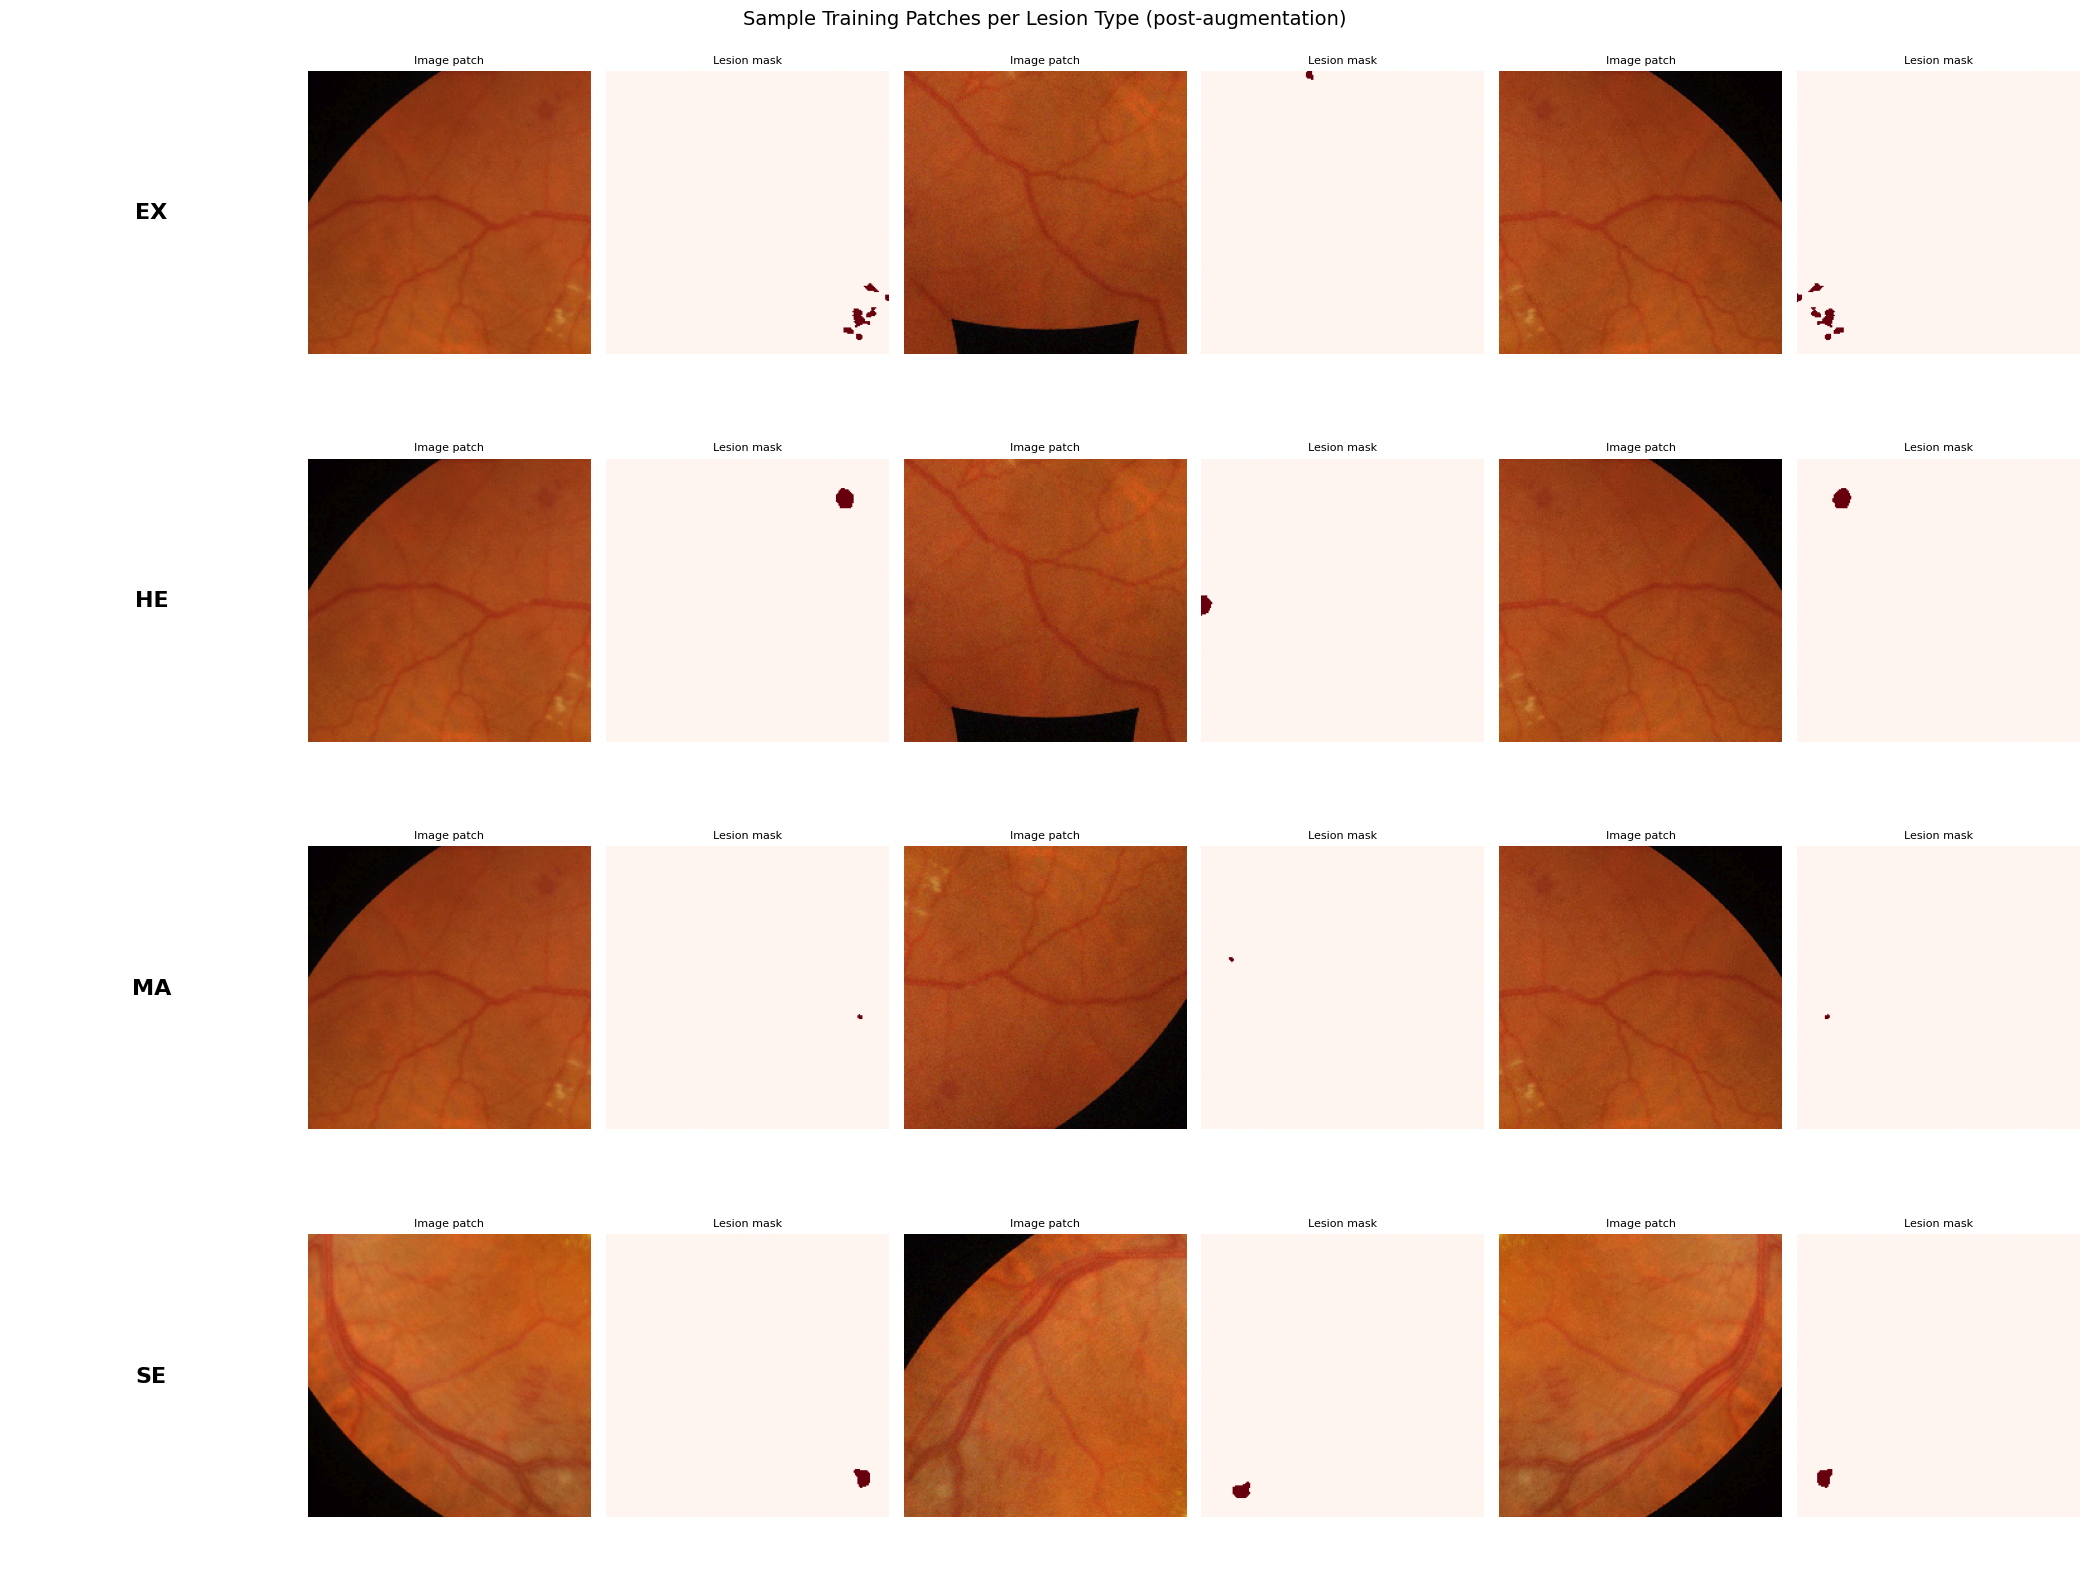


Visualization saved: /content/drive/MyDrive/DR_PROJECT/preprocessed/sample_patches.png
Preprocessing complete. Proceed to Notebook 2 (Segmentation Training + HSA).


In [14]:
# ---- Summary table ----
print(f"\n{'Lesion':<6} {'Train':>8} {'Val':>6} {'Test':>6}  {'Total':>7}")
print('-' * 38)
for lesion in LESIONS:
    out_dir = os.path.join(OUTPUT_BASE, 'segmentation', lesion)
    row = {}
    for split in ['train', 'val', 'test']:
        p = os.path.join(out_dir, f'{split}.npz')
        row[split] = int(np.load(p)['images'].shape[0]) if os.path.exists(p) else 0
    total = sum(row.values())
    print(f"{lesion:<6} {row['train']:>8} {row['val']:>6} {row['test']:>6}  {total:>7}")

# ---- Sample visualisation ----
fig, axes = plt.subplots(len(LESIONS), 7, figsize=(21, 4 * len(LESIONS)))

for r, lesion in enumerate(LESIONS):
    p = os.path.join(OUTPUT_BASE, 'segmentation', lesion, 'train.npz')
    if not os.path.exists(p):
        continue
    d = np.load(p)
    imgs, msks = d['images'], d['masks']
    has_lesion = msks.max(axis=(1, 2)) > 0
    sample_idx = np.where(has_lesion)[0][:3]

    axes[r, 0].text(0.5, 0.5, lesion, ha='center', va='center',
                    fontsize=16, fontweight='bold')
    axes[r, 0].axis('off')

    for c, i in enumerate(sample_idx):
        axes[r, c * 2 + 1].imshow(imgs[i])
        axes[r, c * 2 + 1].set_title('Image patch', fontsize=8)
        axes[r, c * 2 + 1].axis('off')
        axes[r, c * 2 + 2].imshow(msks[i], cmap='Reds')
        axes[r, c * 2 + 2].set_title('Lesion mask', fontsize=8)
        axes[r, c * 2 + 2].axis('off')

plt.suptitle('Sample Training Patches per Lesion Type (post-augmentation)', fontsize=14)
plt.tight_layout()
save_path = os.path.join(OUTPUT_BASE, 'sample_patches.png')
plt.savefig(save_path, dpi=100, bbox_inches='tight')
plt.show()
print(f'\nVisualization saved: {save_path}')
print('Preprocessing complete. Proceed to Notebook 2 (Segmentation Training + HSA).')